In [34]:
import pandas as pd
import seaborn as sns

# Import Data

In [35]:
df = pd.read_csv("../datos_tiempo_angulo.csv")
df

,tiempo(ms),ángulo
0,0,0.0000
1,5,0.0014
2,10,0.0014
3,15,5.6250
4,20,5.6264
...,...,...
96,480,331.8750
97,485,337.5000
98,490,337.5014
99,495,343.1250


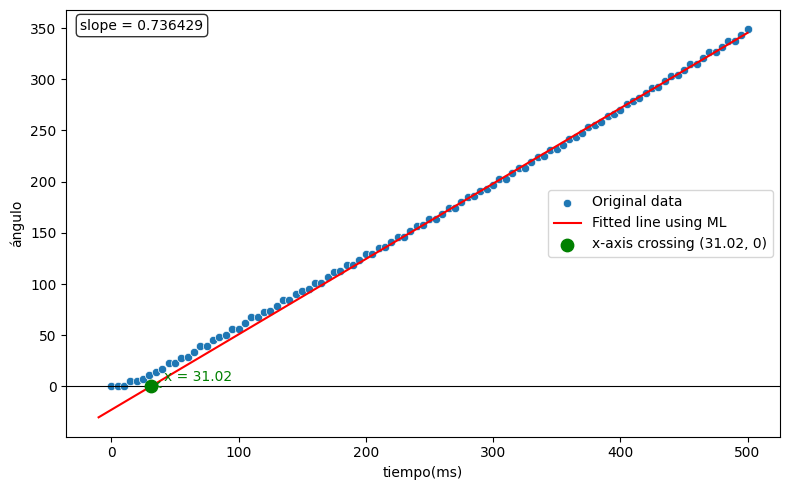

Slope: 0.736429
Intercept: -22.841318
x at y=0: 31.016339


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

linear_df = df[df["tiempo(ms)"] > 200].copy()
X_linear = linear_df[["tiempo(ms)"]].to_numpy()
y_linear = linear_df["ángulo"].to_numpy()

lr = LinearRegression()
lr.fit(X_linear, y_linear)

x_line = np.linspace(-10, X_linear.max(), 200).reshape(-1, 1)
y_line = lr.predict(x_line)

if lr.coef_[0] != 0:
    x_zero = -lr.intercept_ / lr.coef_[0]
else:
    x_zero = np.inf

slope = lr.coef_[0]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="tiempo(ms)", y="ángulo", label="Original data")
plt.plot(x_line, y_line, color="red", label="Fitted line using ML")
plt.axhline(0, color="black", linewidth=0.8)
plt.scatter([x_zero], [0], color="green", s=80, zorder=5, label=f"x-axis crossing ({x_zero:.2f}, 0)")
plt.annotate(
    f"x = {x_zero:.2f}",
    xy=(x_zero, 0),
    xytext=(x_zero + 10, 5),
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green",
)
plt.text(
    0.02,
    0.98,
    f"slope = {slope:.6f}",
    transform=plt.gca().transAxes,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.xlabel("tiempo(ms)")
plt.ylabel("ángulo")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Slope: {lr.coef_[0]:.6f}")
print(f"Intercept: {lr.intercept_:.6f}")
print(f"x at y=0: {x_zero:.6f}")